#  Decision Trees — Intuition, Entropy & Information Gain

Before learning advanced ensemble algorithms like **Random Forest** or **XGBoost**, it's important to understand the foundation: the **Decision Tree**.

A Decision Tree is one of the easiest machine learning algorithms to understand because it works almost exactly like the way humans make decisions—by asking a series of questions.

---

# 1. What is a Decision Tree?

A **Decision Tree** is a flowchart-like machine learning model that makes predictions by asking a sequence of **Yes/No questions** about the features in your dataset.

Each question splits the data into smaller groups.

Eventually, the data reaches a **Leaf Node**, where the final prediction is made.

Think of it like playing **20 Questions**.

Instead of asking random questions, the algorithm asks the **most useful question first**, then continues asking more questions until it can confidently make a prediction.

---

## Example

Suppose we want to predict whether a customer will purchase a premium subscription.

Our target variable is

$$
y=
\begin{cases}
1,& \text{Customer will buy}\\
0,& \text{Customer will not buy}
\end{cases}
$$

A Decision Tree might create a decision process like this:

```text
                 Annual Income > $50,000 ?
                     /               \
                   No                 Yes
                  /                     \
         Won't Buy            Logged in during last 7 days?
                               /                  \
                             No                    Yes
                            /                        \
                    Won't Buy                  Will Buy
```

The model first checks the customer's income.

If the answer is **No**, it immediately predicts **Won't Buy**.

If the answer is **Yes**, it asks another question.

This process continues until the model reaches a final decision.

---

## The Goal of Every Split

Every time a Decision Tree asks a question, it wants to separate the data into groups that are as **pure** as possible.

In simple words,

after each split,

each group should contain mostly **one class**.

For example,

Instead of this:

| Buyers | Non-Buyers |
|---------|------------|
| 50 | 50 |

the algorithm prefers something like

| Buyers | Non-Buyers |
|---------|------------|
| 95 | 5 |

because the second group is much easier to classify.

---

# 2. How Does the Tree Choose the Best Question?

Imagine your dataset has many features.

- Age
- Salary
- Income
- Occupation
- City
- Device Type
- Login Frequency
- Experience

Which feature should the tree split on first?

The answer is:

**It measures how much "disorder" or "chaos" exists in the data.**

The mathematical measure of this chaos is called

# Entropy

---

# 3. Understanding Entropy

Entropy measures **how mixed the classes are** inside a dataset.

You can think of Entropy as a **Chaos Meter**.

- Low entropy → very organized data.
- High entropy → highly mixed data.

---

## Entropy Formula

The entropy of a dataset is

$$
\boxed{
H(S)
=
-\sum_{i=1}^{c}
p_i
\log_2(p_i)
}
$$

where

- $H(S)$ = Entropy of dataset $S$
- $c$ = Number of classes
- $p_i$ = Probability of class $i$

---

## Intuition Behind Entropy

Imagine two buckets of balls.

### Bucket A

```text
🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵
```

Every ball is blue.

If someone asks,

> "Pick one ball. What color will it be?"

You already know the answer.

There is **no uncertainty**.

So,

Entropy is

$$
\boxed{0}
$$

---

### Bucket B

```text
🔵 🔵 🔵 🔵 🔵
🔴 🔴 🔴 🔴 🔴
```

Half the balls are blue.

Half are red.

Now if someone asks,

> "Pick one ball."

You are uncertain.

There is maximum randomness.

Entropy is at its highest value.

---

# 4. Extreme Cases of Entropy

---

## Scenario 1 — Perfectly Pure Dataset

Suppose a bucket contains

100 Buyers

0 Non-Buyers

Then

$$
p=1
$$

Since

$$
\log_2(1)=0
$$

the entropy becomes

$$
\boxed{H(S)=0}
$$

This means

**No uncertainty.**

The dataset is completely pure.

---

## Scenario 2 — Maximum Chaos

Now suppose we have

50 Buyers

50 Non-Buyers

Then

$$
p=0.5
$$

The entropy becomes

$$
H(S)
=
-
\left(
0.5\log_2(0.5)
+
0.5\log_2(0.5)
\right)
$$

Since

$$
\log_2(0.5)=-1
$$

we obtain

$$
H(S)=1
$$

This is the maximum possible entropy for binary classification.

It represents complete uncertainty.

---

# Entropy Summary

| Dataset | Entropy |
|-----------|---------|
| All samples belong to one class | **0** |
| Mostly one class | Low |
| Equal mixture of classes | **1** |

---

# 5. Information Gain

Now that we can measure chaos,

how does the Decision Tree decide which feature to split?

It calculates

# Information Gain (IG)

Information Gain tells us

> **How much does this split reduce the chaos?**

The larger the reduction,

the better the split.

---

## Information Gain Formula

$$
\boxed{
\text{Information Gain}
=
\text{Entropy(Parent)}
-
\sum
\left(
\frac{\text{Child Size}}
{\text{Parent Size}}
\times
\text{Entropy(Child)}
\right)
}
$$

---

## Simple Interpretation

Imagine the parent node has

Entropy = 1

After splitting,

you obtain two child nodes whose weighted entropy equals

0.2

Then

$$
IG
=
1-0.2
=
0.8
$$

This is an excellent split because

the uncertainty has reduced significantly.

---

# How the Algorithm Works

For every feature,

the Decision Tree performs the following steps.

1. Pretend to split using that feature.
2. Compute the entropy of the child nodes.
3. Calculate Information Gain.
4. Repeat for every feature.
5. Choose the feature with the **highest Information Gain**.

This becomes the first question of the tree.

The same process is repeated recursively until the tree is complete.

---

# 6. Gini Impurity

Although Entropy is mathematically elegant,

many machine learning libraries such as **Scikit-Learn** use another impurity measure by default called

# Gini Impurity

Its purpose is exactly the same:

measure how impure a node is.

---

## Gini Formula

$$
\boxed{
\text{Gini}
=
1
-
\sum_{i=1}^{c}
p_i^2
}
$$

---

## Understanding Gini

Like entropy,

- Pure dataset → Gini = 0
- Mixed dataset → Higher Gini

For binary classification,

the maximum Gini impurity is

$$
0.5
$$

which occurs when both classes have equal probability.

---

## Why Does Scikit-Learn Prefer Gini?

Entropy requires logarithms,

which are computationally expensive.

Gini only requires multiplication,

making it much faster to compute.

As a result,

training Decision Trees with Gini is generally faster,

while producing almost the same tree structure as Entropy.

---

# Entropy vs Gini

| Entropy | Gini Impurity |
|----------|---------------|
| Uses logarithms | Uses squares |
| Slightly slower | Faster |
| Maximum value = 1 | Maximum value = 0.5 |
| More mathematically interpretable | More computationally efficient |
| Used in ID3 and C4.5 | Default in Scikit-Learn CART |

---


# Decision Trees — Hyperparameters (Preventing Overfitting)

In the previous section, we learned how a Decision Tree decides **where to split** using **Entropy**, **Gini Impurity**, and **Information Gain**.

But there is a serious problem.

> **A Decision Tree can easily become too smart for its own good.**

If we allow it to grow without any restrictions, it will eventually memorize the training dataset instead of learning the underlying patterns.

This problem is called **Overfitting**.

---

# 1. Why Do Decision Trees Overfit?

A Decision Tree has only one objective:

> **Keep splitting the data until every group becomes as pure as possible.**

If you don't stop it,

the tree will continue asking more and more questions until each leaf contains only one or two training samples.

The result is a huge and extremely complex tree.

---

## Example

Imagine a dataset containing **1,000 customers**.

Among them, there is one unusual customer:

- Age = **19**
- Annual Income = **₹10 Crore**
- Purchased the product

This customer is clearly an **outlier**.

However, an unrestricted Decision Tree may create a branch like

```text
Age < 20 ?
    │
   Yes
    │
Income > ₹10 Crore ?
    │
   Yes
    │
Predict: Purchased
```

Notice what happened.

The tree created an entire branch just to correctly classify **one single customer**.

Instead of learning a general rule,

it memorized one exceptional case.

---

# The Result

The model achieves

- ✅ **100% Training Accuracy**

but

- ❌ Poor Test Accuracy
- ❌ Poor Real-World Performance

because it learned the **noise** instead of the **signal**.

This phenomenon is known as

# Overfitting (High Variance)

---

# 2. How Do We Prevent Overfitting?

Fortunately,

Scikit-Learn provides several **hyperparameters** that control the growth of a Decision Tree.

Think of them as **brakes** on a fast-moving car.

Without brakes,

the tree keeps growing forever.

With properly tuned brakes,

the tree stops at the right time and generalizes much better.

---

# The Four Most Important Hyperparameters

---

# 1. `max_depth`

## What Does It Do?

`max_depth` specifies

> **How many levels deep the tree is allowed to grow.**

It limits the maximum number of questions the tree can ask.

---

### Example

Suppose

```python
max_depth = 3
```

Then the tree can ask at most

- Question 1
- Question 2
- Question 3

After reaching the third level,

the tree **must stop**.

It cannot continue splitting further.

---

### If `max_depth=None`

This is the default behavior.

The tree keeps growing until

- every leaf is pure, or
- no further split is possible.

This often leads to severe overfitting.

---

### Choosing the Right Depth

| Small Depth | Large Depth |
|--------------|-------------|
| Simple model | Complex model |
| May underfit | May overfit |
| High bias | High variance |

In many practical datasets,

values between

```text
3 – 10
```

often provide a good balance,

although the optimal value depends on the dataset.

---

# 2. `min_samples_split`

## What Does It Do?

This parameter specifies

> **The minimum number of samples required before a node is allowed to split.**

---

### Example

Suppose

```python
min_samples_split = 20
```

If a node contains

```text
25 samples
```

the tree **may split**.

But if a node contains

```text
19 samples
```

the tree **must stop**.

No further questions are allowed.

That node immediately becomes a **Leaf Node**.

---

### Why Is This Useful?

Deep inside a tree,

nodes often contain very few samples.

Allowing these tiny nodes to split further usually creates highly specific rules that only describe a handful of observations.

By requiring a minimum number of samples,

we prevent the tree from growing unnecessary branches.

---

# 3. `min_samples_leaf`

## What Does It Do?

This parameter specifies

> **The minimum number of samples that every leaf node must contain.**

Unlike `min_samples_split`,

which controls **whether a node may split**,

`min_samples_leaf` controls

**how small the resulting leaf nodes are allowed to become.**

---

### Example

Suppose

```python
min_samples_leaf = 5
```

The tree is **not allowed** to perform any split that creates

- a leaf with 1 sample,
- a leaf with 2 samples,
- a leaf with 3 samples,
- or a leaf with 4 samples.

Every final leaf must contain **at least five observations**.

---

### Why Is This Important?

Imagine an outlier appears in your dataset.

Without restrictions,

the tree might isolate that single point.

With

```python
min_samples_leaf = 5
```

that is impossible.

The tree is forced to make decisions based on groups of observations rather than individual anomalies.

This makes the model much more robust.

---

# 4. `max_features`

## What Does It Do?

Normally,

when choosing the next split,

a Decision Tree evaluates **every feature** in the dataset.

For example,

suppose your dataset contains

```text
Age
Income
Education
Experience
Occupation
City
Gender
...
```

The tree calculates Information Gain for **all features** and chooses the best one.

---

### Using `max_features`

Instead,

we can tell the tree

> "Don't examine every feature."

For example,

```python
max_features = "sqrt"
```

means

the tree randomly selects only

$$
\sqrt{\text{Total Features}}
$$

before choosing the best split.

Similarly,

```python
max_features = "log2"
```

selects only

$$
\log_2(\text{Total Features})
$$

features.

---

### Why Is This Useful?

Sometimes,

one feature is extremely dominant.

Without randomness,

that same feature appears near the top of the tree every time.

Introducing random feature selection

- reduces dependency on one feature,
- increases diversity,
- produces a more robust model.

This idea later becomes the foundation of

**Random Forests**.

---

# Visual Intuition

Imagine plotting the decision boundary of an unrestricted Decision Tree.

Instead of smooth regions,

you would see something like this:

```text
□□□□□□□□□■■□□□■■□□
□□■■□□□□■■□□□□□■□
■□□□■■□□□■■□□■■□
□□■■□□■■□□□□□□□■
```

The boundary twists and turns,

trying to perfectly capture every single training point.

This is a classic sign of **overfitting**.

---

Now suppose we train the tree using

```python
max_depth = 4

min_samples_leaf = 10
```

The decision boundary becomes much simpler.

Instead of hundreds of tiny regions,

the tree creates only a few large regions that represent the overall structure of the data.

It may misclassify a few noisy observations,

but it performs much better on unseen data.

---

# Summary of Hyperparameters

| Hyperparameter | Purpose | Prevents |
|----------------|---------|-----------|
| `max_depth` | Limits how deep the tree can grow | Overfitting due to excessive depth |
| `min_samples_split` | Minimum samples required before splitting | Tiny internal branches |
| `min_samples_leaf` | Minimum samples allowed in every leaf | Outlier memorization |
| `max_features` | Uses only a subset of features for splitting | Dominance of a few features and improves robustness |

---


# Phase 3: Coding a Real Production Pipeline & Visualizing the Tree
Now we take theory and put it into code. We are going to throw the same non-linear, messy Moons Dataset (that we used for SVMs) at a Decision Tree.

We will run two experiments side-by-side:

1. The Overfitted Monster: An unrestricted tree with no hyperparameters.

2. The Pruned Professional: A structurally controlled tree using max_depth and min_samples_leaf.

Finally, we will use Scikit-Learn's built-in plot_tree function to physically print out the flowchart so you can read the exact mathematical logic the model invented.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier, plot_tree
from matplotlib.colors import ListedColormap

In [2]:
# Using the moons dataset with noise to create overlapping, realistic data
X, y = make_moons(n_samples=200, noise=0.20, random_state=42)

In [3]:
# build the visualization engine
def plot_tree_boundary(model, X, y, ax, title):
    # Setup color maps
    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_bold = ['darkred', 'darkblue']

    # Create evaluation meshgrid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Predict across the entire grid to draw boundaries
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot background quadrants
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.5)

    # Scatter original data
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(cmap_bold),
               edgecolors='k', s=35)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(())
    ax.set_yticks(())

In [4]:
# train the two trees
unrestricted_tree = DecisionTreeClassifier(random_state=42)
unrestricted_tree.fit(X, y)

# Model B: Pruned (Will generalize using Hyperparameters)
# We limit depth to 4 questions, and force at least 5 samples per final bucket
pruned_tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)
pruned_tree.fit(X, y)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)

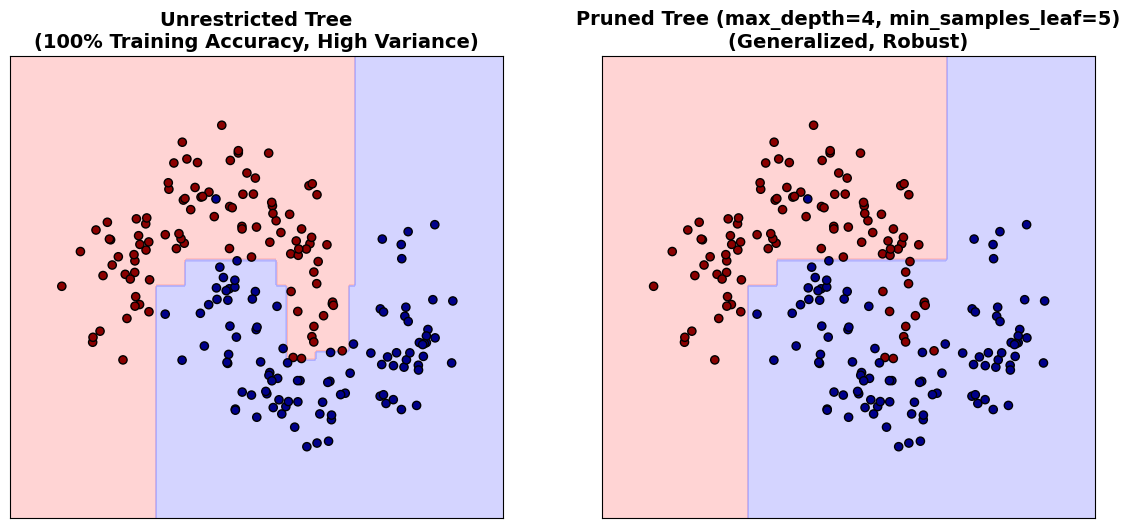

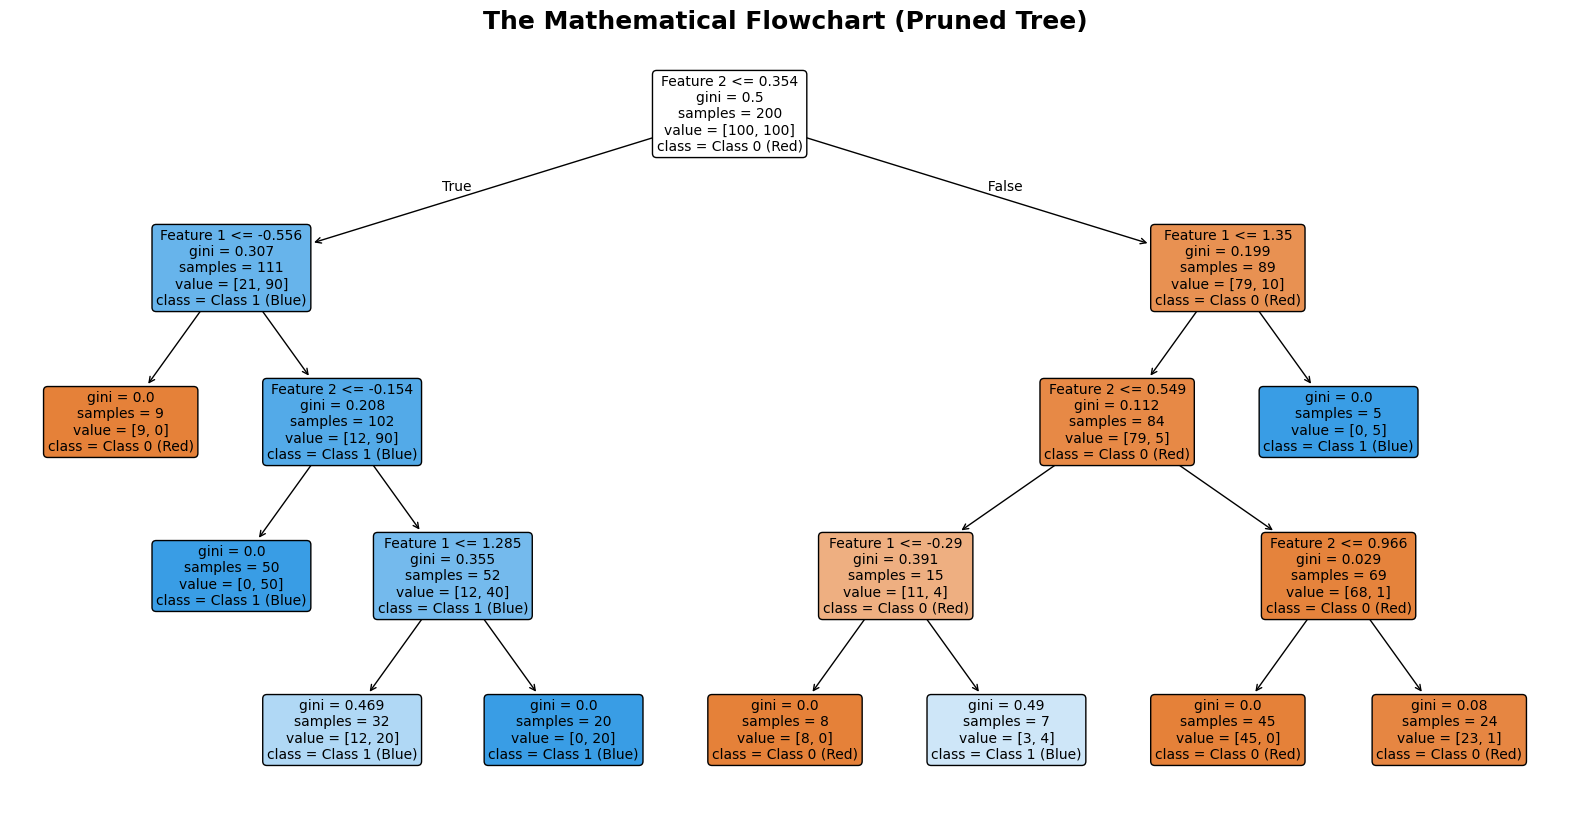

In [6]:
# Visualize decision boundaries
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_tree_boundary(unrestricted_tree, X, y, axes[0],
                   "Unrestricted Tree\n(100% Training Accuracy, High Variance)")
plot_tree_boundary(pruned_tree, X, y, axes[1],
                   "Pruned Tree (max_depth=4, min_samples_leaf=5)\n(Generalized, Robust)")
plt.show()


# STEP 5: VISUALIZE THE ACTUAL FLOWCHART LOGIC
plt.figure(figsize=(20, 10))
# We plot the pruned tree so it fits nicely on the screen
plot_tree(pruned_tree, filled=True, feature_names=['Feature 1', 'Feature 2'],
          class_names=['Class 0 (Red)', 'Class 1 (Blue)'], rounded=True, fontsize=10)
plt.title("The Mathematical Flowchart (Pruned Tree)", fontsize=18, fontweight='bold')
plt.show()

1. The Boundary Comparison (Graph 1 vs Graph 2)
- The Unrestricted Tree (Left): Look at the decision boundary. It is an absolute mess of jagged, hyper-specific little rectangles. You will notice isolated tiny boxes (sometimes just fitting a single red dot in a sea of blue). The model memorized the noise perfectly. If a new point lands near one of those micro-boxes tomorrow, it will be misclassified.

- The Pruned Tree (Right): Notice how the jagged edges are gone. The model was forced to draw sweeping, generalized vertical and horizontal lines. It willingly sacrifices a few noisy points (letting some red dots sit in the blue zone) to ensure the overall structural logic is sound. This is a model that survives in production.

2. Reading the Flowchart (The Tree Plot)
Look at the massive flowchart generated in the final output. Every single box (node) contains a wealth of mathematical insight:

- The Split Condition (e.g., Feature 2 <= 0.25): This is the question the model is asking. If the data point meets this condition, it travels down the Left arrow (True). If not, it travels Right (False).

- gini = ...: This is the chaos score! Notice how the top root node starts with a high Gini score (near 0.5). As you travel further down the branches, the Gini score drops closer and closer to 0.0 as the buckets become purer.

- samples = ...: How many data points made it to this specific bucket.

- value = [X, Y]: The actual class breakdown of the bucket (e.g., [45, 5] means 45 Class 0 points and 5 Class 1 points).

- Color Coding: The darker the color of the box (deep orange or deep blue), the purer the final prediction is. White or light boxes indicate the model is highly uncertain.